In [1]:
#necessary module
import os ; import sys
sys.path.append(os.getcwd()+"/Equantum")
#path to data
datapath="/scratch/zhaoyuha/Datas/EQuantum_data/dotgate_center/"
setuppath="/scratch/zhaoyuha/Datas/EQuantum_data/dotgate_center/setup/"
from sites import Site
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from fsc import FSC
import scipy.linalg as sl
import scipy.constants as sc
import importlib
import poissonsolver as psolver
import kwant
import scipy.io as sio

%matplotlib widget

from EQsystem import System

In [2]:
import fsc
importlib.reload(fsc)
from fsc import FSC

import EQsystem
importlib.reload(EQsystem)
from EQsystem import System
#test module


from scipy.interpolate import interp1d
from scipy.optimize import brentq

import poissonsolver
importlib.reload(poissonsolver)

<module 'poissonsolver' from '/scratch/zhaoyuha/Projects/EQuantum/EQuantum/Equantum/poissonsolver.py'>

In [3]:
import qbuilder
importlib.reload(qbuilder)
import poissonsolver
importlib.reload(poissonsolver)
import poissonsolver as psolver

In [4]:
import solvers
importlib.reload(solvers)
from solvers import local_solver

## Define system

In [5]:
def density_function(z):
        spacing0 = 0.015 # spacing at r=0
        k = 0.  # spacing increases by 0.05 per unit distance
        return spacing0 + k * z

In [5]:
def density_function(z):
        spacing0 = 0.011 # spacing at r=0
        k = 0.2  # spacing increases by 0.05 per unit distance
        if abs(z)<3*spacing0:
            return spacing0   #define same lattice for the layers above/beneath quantum system, avoid oscillation due to the lattice mismatch
        else:
            return spacing0 + k * z

In [6]:
geoparams={"lattice_type": "square",   # or honeycomb_lattice, etc.
"box_size": ((-0.6, 0.6), (-0.6, 0.6), (-0.08, 0.08)),
"sampling_density_function": density_function,
"quantum_center": (0,0,0)     # optional, defaults to (0,0,0)
              }

## Initialize System

In [7]:
import os
import hashlib
import inspect

def get_geoparams_hash(params, *funcs):
    params_repr = {}
    for k, v in params.items():
        if callable(v):
            try:
                params_repr[k] = inspect.getsource(v).strip()
            except Exception:
                params_repr[k] = str(v)
        else:
            params_repr[k] = str(v)
            
    for f in funcs:
        try:
            params_repr[f.__name__] = inspect.getsource(f).strip()
        except Exception:
            pass
            
    # Sort keys for consistent hashing
    params_str = str(sorted(params_repr.items()))
    return hashlib.md5(params_str.encode()).hexdigest(), params_repr

current_hash, params_repr = get_geoparams_hash(geoparams, density_function)

hash_folder = os.path.join(setuppath, f"setup_{current_hash}")
hash_file = os.path.join(hash_folder, "geoparams_hash.txt")
sites_file = os.path.join(hash_folder, "sites.json")
readme_file = os.path.join(hash_folder, "README.txt")


generate_sites = True
if os.path.exists(hash_folder) and os.path.exists(sites_file) and os.path.exists(hash_file):
    with open(hash_file, "r") as f:
        saved_hash = f.read().strip()
    if saved_hash == current_hash:
        generate_sites = False
        print(f"Settings unchanged. Found existing setup in {hash_folder}. Skipping generation.")

if generate_sites:
    print(f"Generating new setup in {hash_folder}...")
    os.makedirs(hash_folder, exist_ok=True)
    syst=System(geoparams,assign_mat=False)
    syst.export_sites(filename=sites_file)
    with open(hash_file, "w") as f:
        f.write(current_hash)
    with open(readme_file, "w") as f:
        f.write("Parameter settings for this setup:")
        for k, v in params_repr.items():
            f.write(f"{k}:{v}")

Settings unchanged. Found existing setup in /scratch/zhaoyuha/Datas/EQuantum_data/dotgate_center/setup/setup_7652d749b55d933a16606b6f95fbda03. Skipping generation.


## Initialized Setup

In [8]:
setuppathupdate=hash_folder
config_file=setuppathupdate+"/updated_sites_dot.json"
syst=System(geoparams,config_file=config_file,ifqsystem=True,quantum_builder="default")

Generated 103902 points in 3D.
Voronoi cells have been created.
23 sites have been removed from the system.
Vacuum pruning: removed 48023 sites
The quantum system has been built using the default solver.
Quantum system is generated using default.
EQsystem is successfully initialized.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


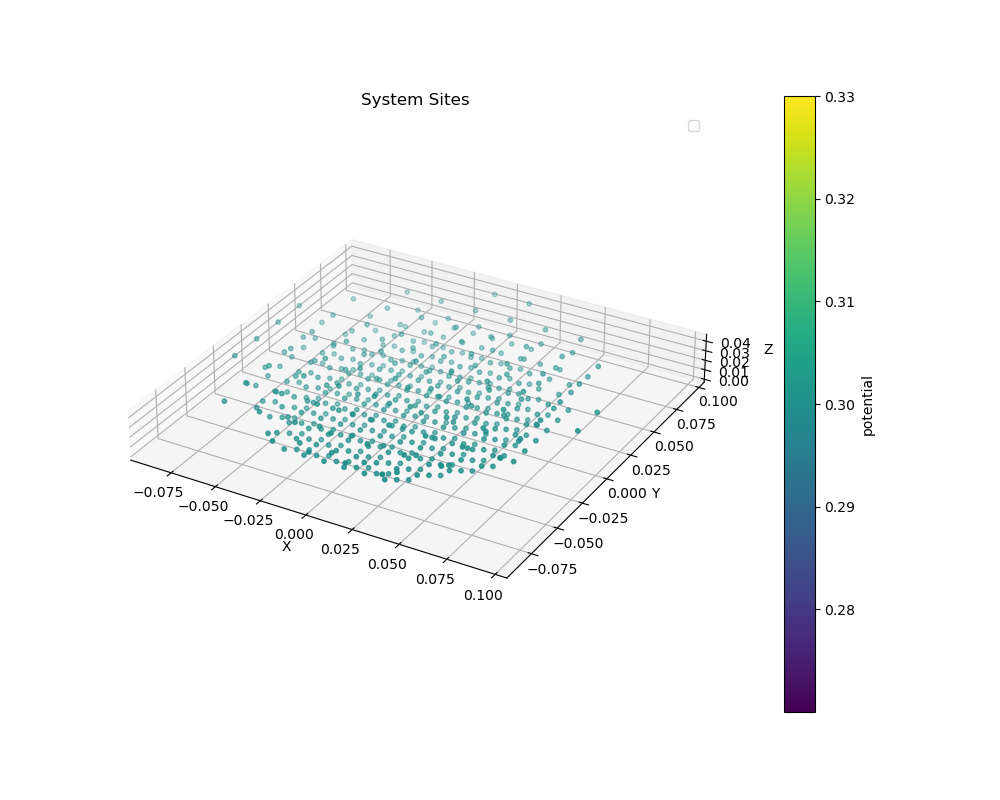

In [9]:
syst.plot_geometry(material='gate',prop='potential')

### Initialize without blender setup (dot)

In [21]:
syst=System(geoparams,ifqsystem=True,quantum_builder="default")

Generated 42315 points in 3D.
Voronoi cells have been created.
1 sites have been removed from the system.
Quantum system is generated using default.
EQsystem is successfully initialized.


## Initialize Quantum problem

In [11]:
qparams={'Ufunc': lambda x:0,'phi':0.0884}
fsc=FSC(syst,ifinitial=False,qparams=qparams,approx="TF")

🔄 Full Hamiltonian rebuild (qparams change)
site_map: 0.0010488680563867092
update_U: 0.2395833688788116
LDOS is calculated through kpm as a whole system.
update_ildos: 0.531138673890382
alloc+fill: 0.010531609877943993
copy back: 0.015888741007074714


In [14]:
boundary_condition={
    'gate': {'potential': -1},
    'dielectric': {'dielectric_constant': 4},
    'backgate': {'potential': 1}}
fsc.update_BC(updates=boundary_condition,ifinitial=True)

The poisson problem has been initialized.


## Check the Spectrum

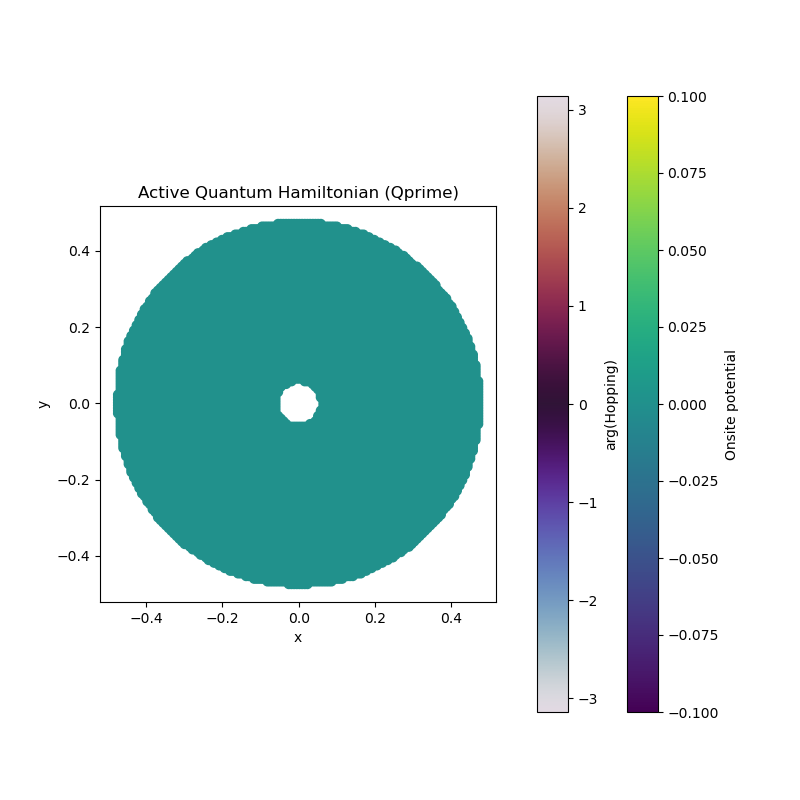

14228


In [31]:
fsc.plot_Hamiltonian()
print(len(fsc.Qsites))

In [ ]:
ltest = qbuilder.update_ildos(
    fsc, syst,
    approx="ED",
    eta=0.0001,
    Ncore=20,
    M=512,
    eps=0.05,
    kernel="jackson",
)

In [21]:
Htest=fsc.qsystem.get_hamiltonian().toarray()
evals,evecs=sl.eigh(Htest)

In [31]:
ErangeT=np.linspace(emin,emax,int(fsc.qsystem.N/2))

In [29]:
emin,emax=fsc.qsystem.get_energy_bounds()

In [32]:
weights=np.abs(evecs)**2

In [63]:
dE=ErangeT[None,:]-evals[:,None]
eta=0.0001
kernal=np.exp(-0.5*(dE/eta)**2)/(np.sqrt(2*np.pi)*eta)

In [67]:
fsc.t/20

0.0001263675660416206

In [64]:
rho_all=weights@kernal

In [39]:
weights.shape

(1751, 1751)

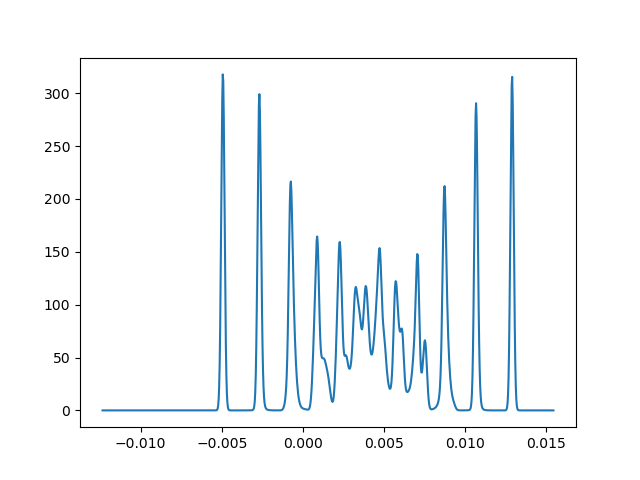

In [65]:
plt.figure()
plt.plot(ErangeT,rho_all[300,:])
plt.show()

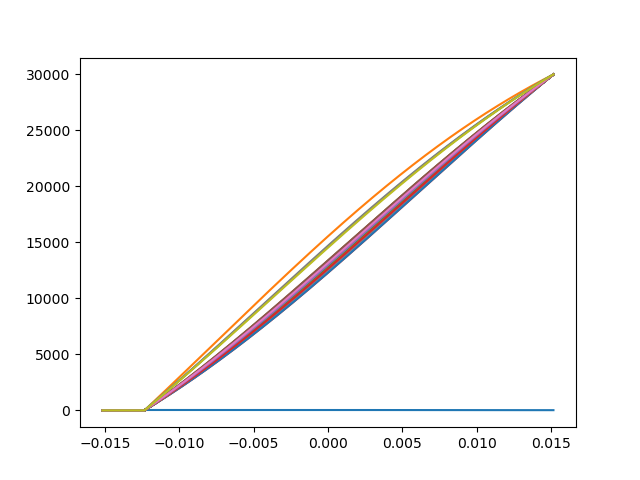

In [16]:
plt.figure()
plt.plot(ltest[1][0],ltest[1][1])
for ii in range(0,len(ltest),20):
    plt.plot(ltest[ii][0],[np.sum(ltest[ii][1][:idx]) for idx in range(len(ltest[ii][0]))])
plt.show()

In [195]:
E = np.asarray(ildos[0], dtype=float)
rho = np.asarray(ildos[1], dtype=float)

n_from_ldos = np.trapz(rho, E)
print("Integrated LDOS =", n_from_ldos)
print("ni =", ni)
print("max_fill =", fsc.max_fill)

Integrated LDOS = 313.2586733495183
ni = -168.444224033846
max_fill = 313.25867334951835


In [56]:
np.min(fsc.Ui[fsc.Qsites])

0.0

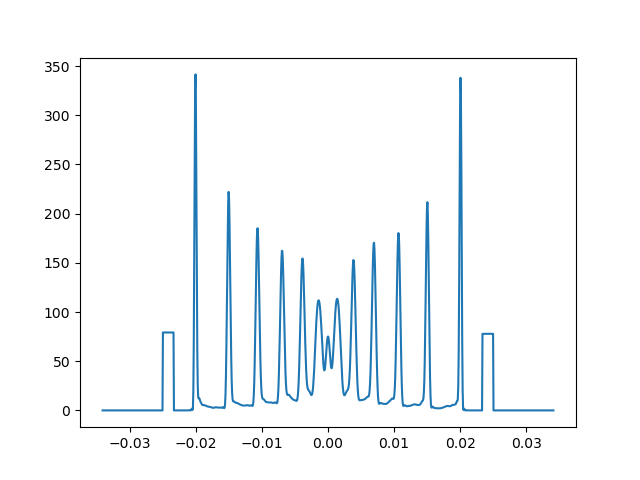

In [16]:
plt.figure()
plt.plot(x_dis,y_dis)
plt.show()

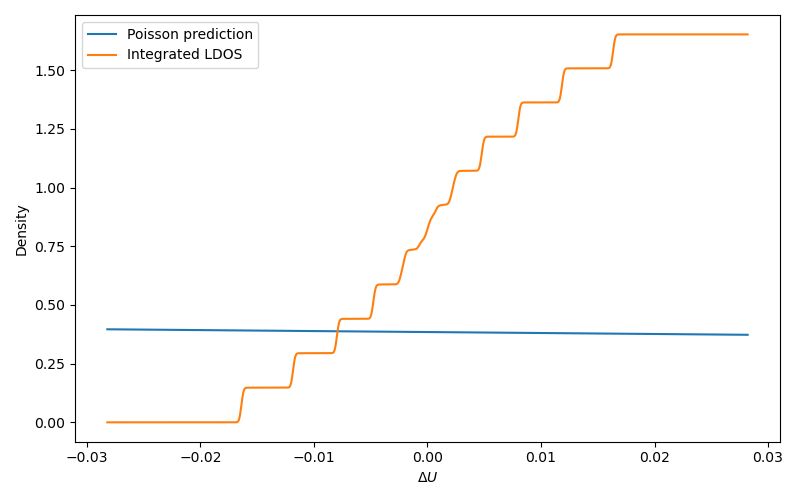

In [15]:
qidx = 2500  # index in Qprime

site_id = fsc.Qprime[qidx]
sidx = np.where(np.array(fsc.Qsites) == site_id)[0][0]

ni = fsc.ni[site_id]
Ci = fsc.Ci[qidx]
ildos = fsc.ildos[sidx]
Ui = fsc.Ui[site_id]

x_dis = np.asarray(ildos[0], dtype=float) - Ui
y_dis = np.asarray(ildos[1], dtype=float)

# cumulative integral using trapezoidal rule
ildos_dis = np.zeros_like(y_dis, dtype=float)
ildos_dis[1:] = np.cumsum(0.5 * (y_dis[1:] + y_dis[:-1]) * np.diff(x_dis))

ildos_interp = interp1d(
    x_dis,
    ildos_dis,
    kind='linear',
    fill_value='extrapolate',
    bounds_error=False
)

def dn_for_Ci(dU):
    return dU * Ci + ni

def diff(dU):
    return np.abs(dn_for_Ci(dU) - ildos_interp(dU))

plt.figure(figsize=(8, 5))
plt.plot(x_dis, [dn_for_Ci(dU) for dU in x_dis], label="Poisson prediction")
plt.plot(x_dis, ildos_dis, label="Integrated LDOS")
#plt.plot(x_dis, [diff(dU) for dU in x_dis], label="Mismatch")
plt.xlabel(r"$\Delta U$")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [206]:
E = np.asarray(fsc.ildos[sidx][0], dtype=float)
rho = np.asarray(fsc.ildos[sidx][1], dtype=float)

print("Integral =", np.trapz(rho, E))
print("max_fill =", fsc.max_fill)

Integral = 313.2586733495183
max_fill = 313.25867334951835


In [210]:
syst.lat_spacing

0.03

In [17]:
fsc.get_energy_bounds()[1]/fsc.t

10.812728895330242

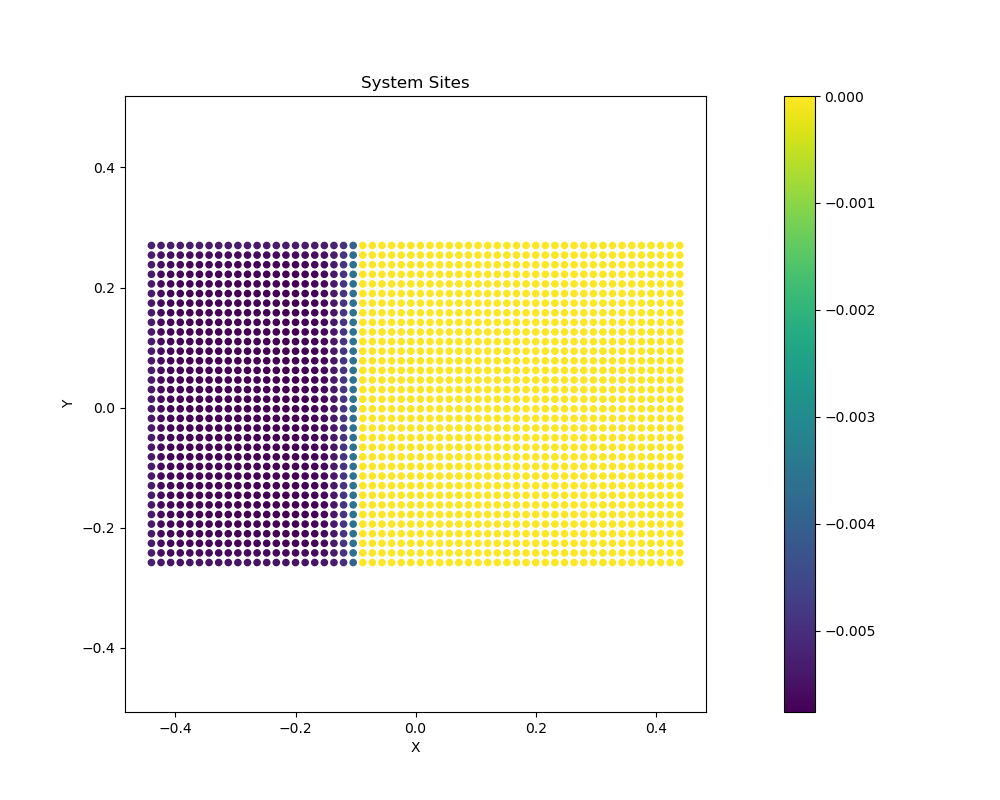

-0.0021738937848903945


In [104]:
fsc.plot_qsystem(fsc.Ui[fsc.Qsites])
print(np.mean(fsc.Ui[fsc.Qsites]))

In [22]:
E = np.asarray(ildos[0], dtype=float)
rho = np.asarray(ildos[1], dtype=float)
print(np.trapz(rho, E), fsc.max_fill)

313.2586733495183 313.25867334951835


In [28]:
Htest=fsc.qsystem.H.toarray()
pot=np.diagonal(Htest)

In [29]:
ev=np.sort(sl.eigvals(Htest))

In [31]:
ildos=qbuilder.update_ildos(
    fsc, syst,
    approx="TF",
    Ncore=20,
    M=512,
    eps=0.05,
    kernel="jackson",
)

/scratch/zhaoyuha/miniconda3/envs/equant/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


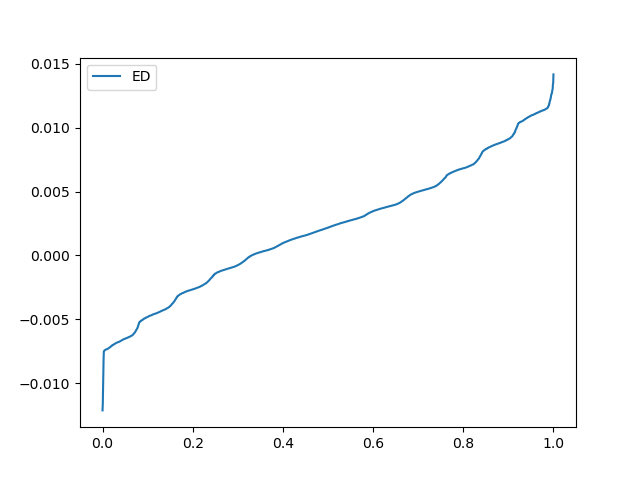

In [34]:
nden=np.array([np.sum(ildos[0][1][:idx])for idx,ee in enumerate(ildos[0][0])])
plt.figure()
plt.plot(np.linspace(0,1,len(ev)),ev,label='ED')
#plt.plot(nden/nden[-1],ildos[0][0]-fsc.energy_bounds,label='kpm')
plt.legend()
plt.show()

## Plot System

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


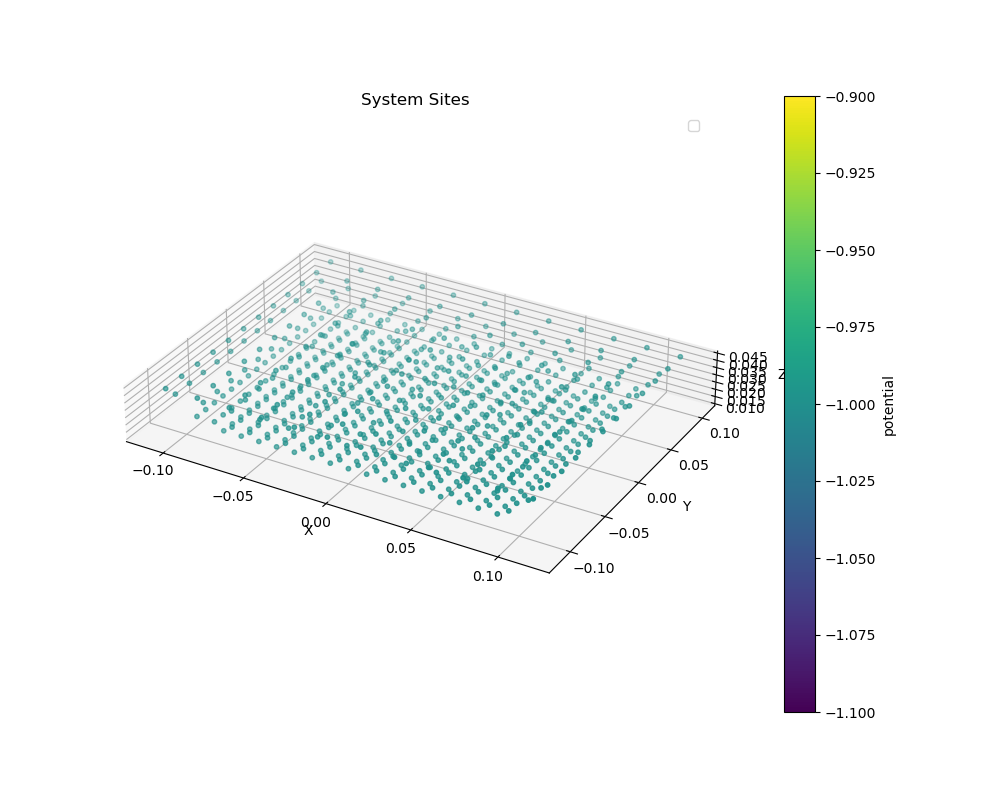

In [32]:
syst.plot_geometry(material='gate',prop='potential')

In [37]:
gateidx=np.zeros(fsc.num_sites)
for qidx, site in enumerate(fsc.sites.values()): #for all sites in the quantum system
    if site.material=='Qsystem':
        gateidx[qidx]=fsc.Ui[qidx]
gateidx[gateidx==0]='nan'

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


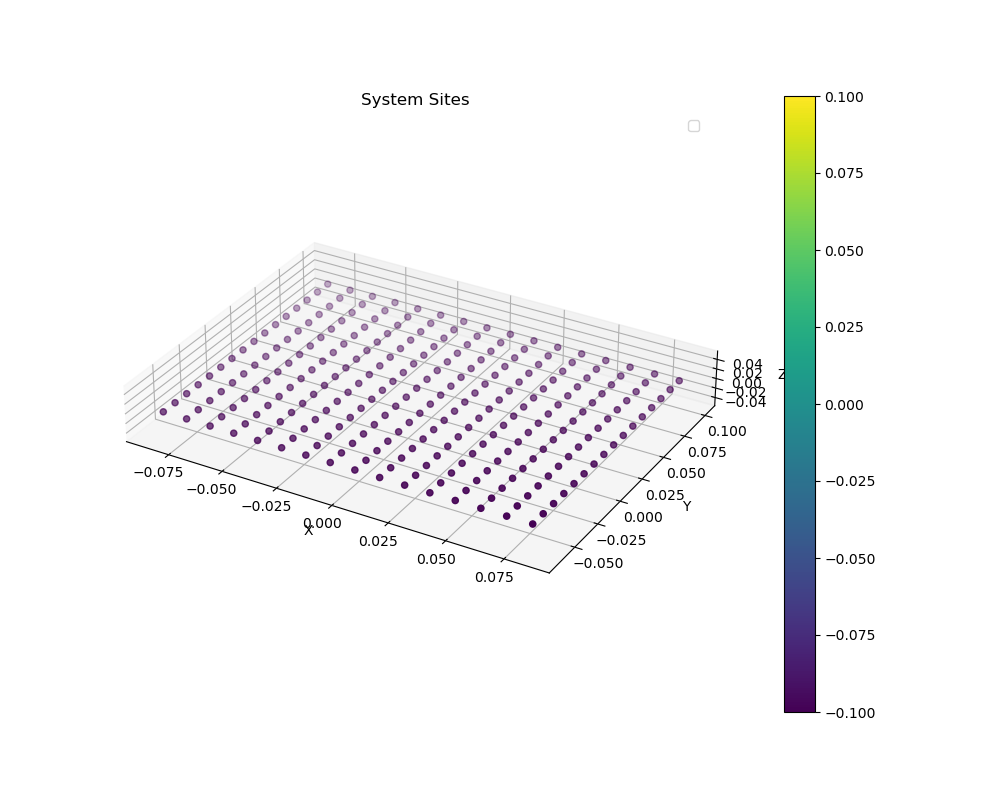

In [38]:
indicate=np.zeros(len(fsc.sites))
indicate[fsc.D_indices]=1
fsc.plot_full(gateidx)

In [94]:
num_neighbor=np.zeros(fsc.num_sites)
for qidx, idx in enumerate(fsc.Qsites): #for all sites in the quantum system
    for neighbor in fsc.sites[idx].neighbors:
        if fsc.sites[neighbor].material=='gate':  # if the neighboring sites also belongs to the Qsystem
            num_neighbor[idx]+=1


In [196]:
indicate=np.zeros(len(fsc.Qsites))
for idx in cut_idx:
    indicate[idx]=fsc.ni[fsc.Qprime][idx]

IndexError: index 7373 is out of bounds for axis 0 with size 7321

In [22]:
for neighbor in fsc.sites[fsc.Qsites[2370]].neighbors:
    print(fsc.sites[neighbor].material)

Qsystem
dielectric
dielectric
Qsystem
Qsystem


In [45]:
indicate=np.zeros(fsc.num_sites)
for idx, qidx in enumerate(fsc.Qprime):
    indicate[qidx]=fsc.Ci[idx]

/tmp/ipykernel_1024784/828773061.py:6: RuntimeWarning: invalid value encountered in log
  fsc.plot_qsystem(np.log(plotdata))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


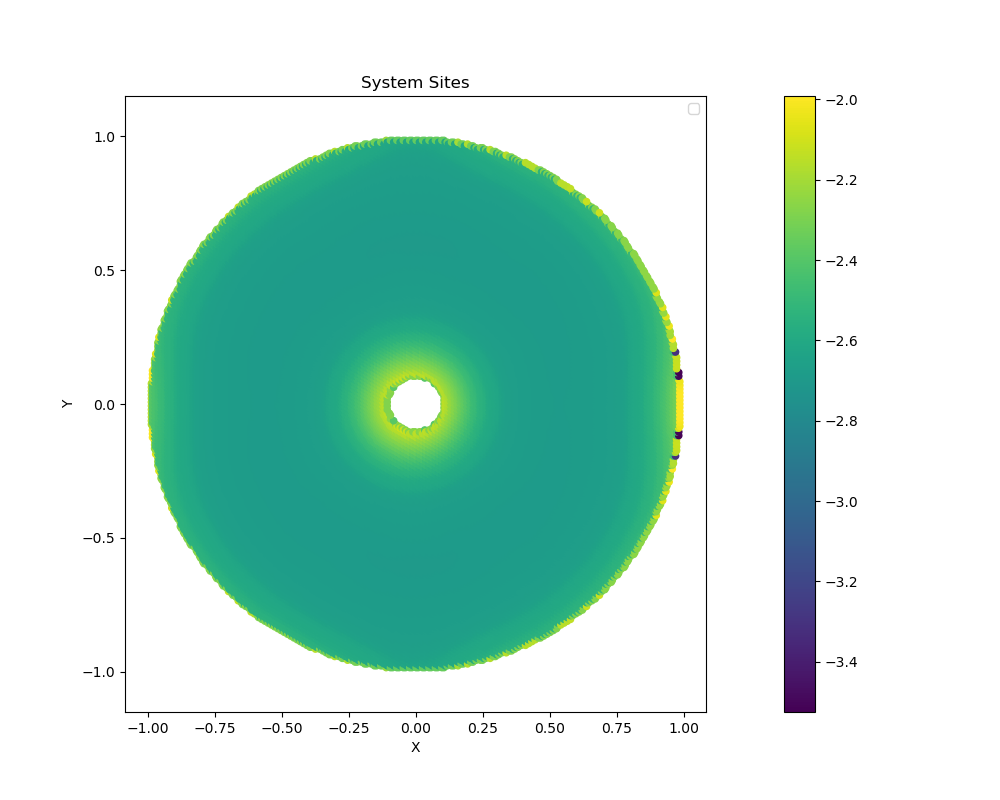

In [13]:
#indicate=np.zeros(fsc.num_sites)
#indicate[fsc.Qprime[1929]]=1
plotdata=Uis[1,:][fsc.Qsites]
#plotdata=dUdn[1]
#plotdata=pot
fsc.plot_qsystem(np.log(plotdata))

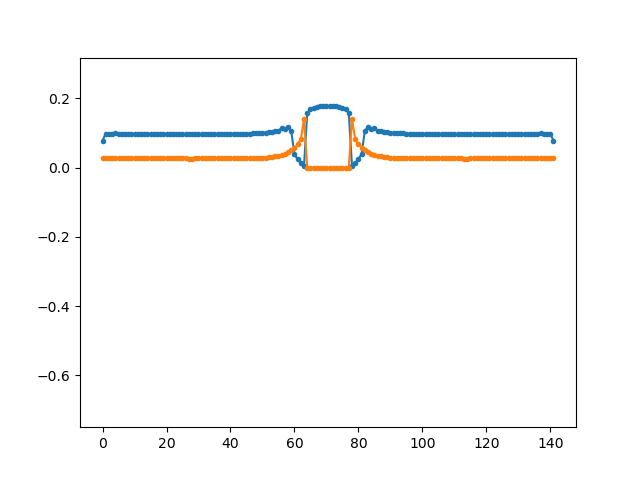

In [46]:
cut_idx=[idx for idx in range(len(fsc.Qsites)) if np.abs(fsc.sites[fsc.Qsites[idx]].coordinates[0])<0.002 and fsc.sites[fsc.Qsites[idx]].material=='Qsystem']
plt.figure()
plt.plot(Uis[-1,:][fsc.Qsites][cut_idx],'.-')
plt.plot(fsc.ni[fsc.Qsites][cut_idx],'.-')
#plt.plot(fsc.Ci[cut_idx])
plt.ylim([-0.75,2*fsc.bandwidth])
plt.show()

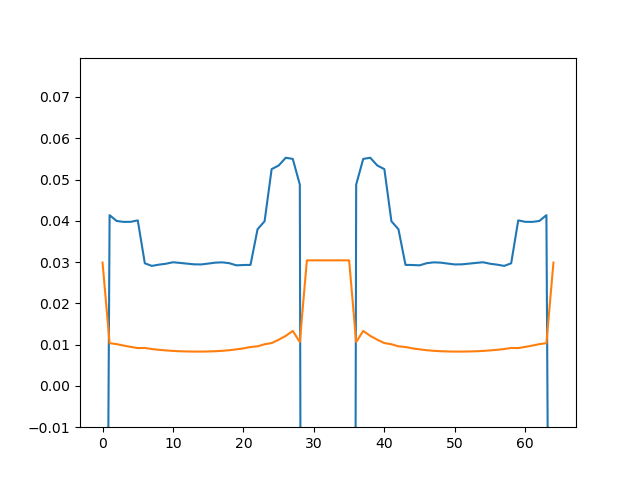

In [127]:
cut_idx=[idx for idx in range(len(fsc.Qsites)) if np.abs(fsc.sites[fsc.Qsites[idx]].coordinates[0])<0.005 and fsc.sites[fsc.Qsites[idx]].material=='Qsystem']
plt.figure()
plt.plot(fsc.Ui[fsc.Qsites][cut_idx])
plt.plot(fsc.ni[fsc.Qsites][cut_idx])
#plt.plot(fsc.Ci[cut_idx])
plt.ylim([-0.01,fsc.bandwidth])
plt.show()

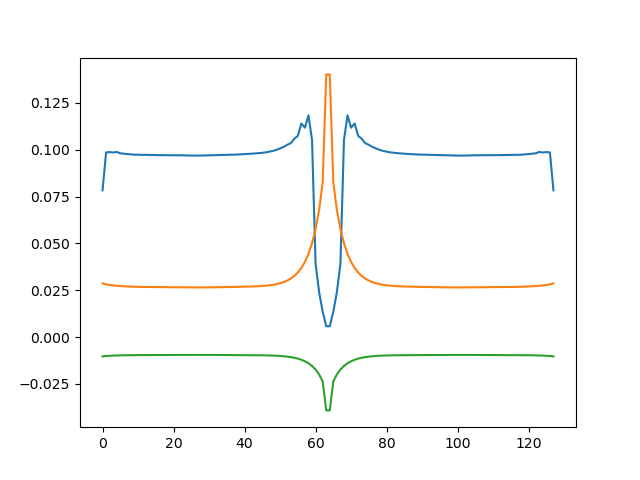

In [47]:
cut_idx=[idx for idx in range(len(fsc.Qprime)) if np.abs(fsc.sites[fsc.Qprime[idx]].coordinates[0])<0.002 and fsc.sites[fsc.Qprime[idx]].material=='Qsystem']
plt.figure()
plt.plot(Uis[-1,:][fsc.Qprime][cut_idx])
plt.plot(fsc.ni[fsc.Qprime][cut_idx])
plt.plot(0.1*fsc.Ci[cut_idx])
plt.show()

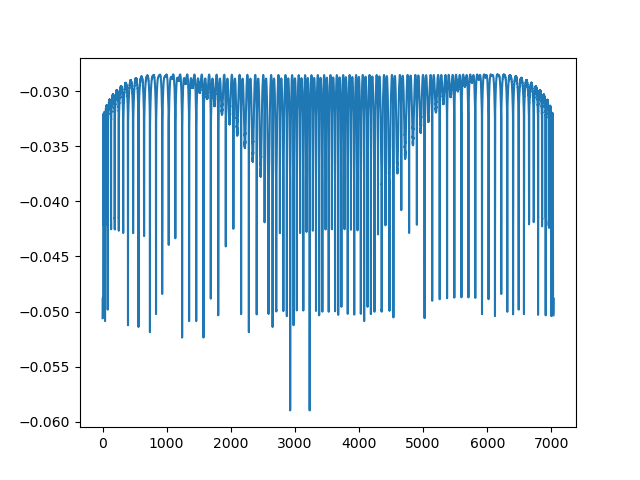

In [72]:
plt.figure()
#plt.plot(fsc.Ui[fsc.Qprime][cut_idx])
#plt.plot(fsc.ni[fsc.Qprime][cut_idx])
plt.plot(fsc.Ci)
plt.show()

## Solve FSC

In [ ]:
fsc.Ncore=20
fsc.convergence_tol=[1e-4,1e-2]
fsc.solve(
    syst,
    save=True,
    snapshot_mode="step",
    snapshot_every=1,
    snapshot_folder=setuppathupdate+"/fsc_logs_ED_e_4_alpha_0.4",
    save_ildos=True,
    ldos_method="ED",
    eta=0.00015,
    #M=256,
    #eps=0.05,
    #kernel="jackson",
)

Iteration counts [Step I, Step II, Step III]: [0, 0, 0]
Solver streak: None, 0

--- Iteration 0 ---
Qprime size   : 5645
max |Δn|      : 1.683e-13
|Δn| per site  : 3.304e-15
|Δn| per site % : -6.830e-15
max |ΔILDOS|  : 6.864e+02
|ΔILDOS| per site  : 3.587e+01
|ΔILDOS| per site % : 4.699e+03
last Poisson  : 7.083 s
last Quantum  : 45.597 s
0.2402123063064514 0.11813929944703054
Iteration counts [Step I, Step II, Step III]: [0, 1, 0]
Solver streak: poisson, 1

--- Iteration 1 ---
Qprime size   : 5645
max |Δn|      : 3.232e-02
|Δn| per site  : 1.571e-03
|Δn| per site % : 3.087e-04
max |ΔILDOS|  : 6.864e+02
|ΔILDOS| per site  : 3.587e+01
|ΔILDOS| per site % : 4.699e+03
last Poisson  : 6.587 s
last Quantum  : 45.597 s
0.14400689114086043 0.07078207709065501
Iteration counts [Step I, Step II, Step III]: [0, 2, 0]
Solver streak: poisson, 2

--- Iteration 2 ---
Qprime size   : 5645
max |Δn|      : 1.645e-02
|Δn| per site  : 8.579e-04
|Δn| per site % : 1.466e-04
max |ΔILDOS|  : 6.864e+02
|ΔILDO